# 8-Class Semiconductor Defect Detection
## Complete Dataset: 12,516 Images

**Classes**: bridge, clean, cmp_scratch, crack, film_residue, ler, other, particles

## 1. Setup & Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

np.random.seed(42)
tf.random.set_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU Available: {len(gpus)} device(s)")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️  No GPU detected, using CPU")

print(f"✅ TensorFlow version: {tf.__version__}")

⚠️  No GPU detected, using CPU
✅ TensorFlow version: 2.13.1


## 2. Configuration

In [4]:
DATASET_ROOT = r"C:\Mugi\Projects\IISE\AI model\Dataset"
OUTPUT_DIR = r"C:\Mugi\Projects\IISE\AI model\outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = ['bridge', 'clean', 'cmp_scratch', 'crack', 'film_residue', 'ler', 'other', 'particles']
NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
INITIAL_EPOCHS = 5
FINE_TUNE_EPOCHS = 50
INITIAL_LR = 0.001
FINE_TUNE_LR = 0.0001

print("="*70)
print("8-CLASS DEFECT DETECTION - COMPLETE DATASET")
print("="*70)
print(f"Classes: {', '.join(CLASS_NAMES)}")
print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print("="*70)

8-CLASS DEFECT DETECTION - COMPLETE DATASET
Classes: bridge, clean, cmp_scratch, crack, film_residue, ler, other, particles
Image size: (224, 224)
Batch size: 32


## 3. Data Loading

In [5]:
def load_images_from_folder(folder_path, class_idx, img_size=IMG_SIZE):
    """Load images from folder, checking both direct files and images/ subdirectory."""
    images, labels = [], []
    folder = Path(folder_path)
    
    if not folder.exists():
        return images, labels
    
    # Check for images/ subdirectory (for cracks and Scratch)
    images_subdir = folder / 'images'
    search_path = images_subdir if images_subdir.exists() else folder
    
    # Get all image files
    image_files = []
    for ext in ['*.png', '*.PNG', '*.jpg', '*.JPG', '*.jpeg', '*.JPEG', '*.bmp', '*.BMP']:
        image_files.extend(list(search_path.glob(ext)))
    
    for img_path in image_files:
        try:
            img = keras.preprocessing.image.load_img(str(img_path), target_size=img_size, color_mode='grayscale')
            img_array = keras.preprocessing.image.img_to_array(img)
            images.append(img_array)
            labels.append(class_idx)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
    
    return images, labels

# Folder mappings for each class
class_folders = {
    'bridge': 'Bridge',
    'clean': 'clean',
    'cmp_scratch': 'Scratch',
    'crack': 'cracks',
    'film_residue': 'film_residue',
    'ler': 'LER',
    'other': 'Other',
    'particles': 'particles'
}

# Split names (some use 'valid' instead of 'val')
split_names = {
    'bridge': {'train': 'train', 'val': 'val', 'test': 'test'},
    'clean': {'train': 'train', 'val': 'val', 'test': 'test'},
    'cmp_scratch': {'train': 'train', 'val': 'valid', 'test': 'test'},
    'crack': {'train': 'train', 'val': 'valid', 'test': 'test'},
    'film_residue': {'train': 'train', 'val': 'val', 'test': 'test'},
    'ler': {'train': 'train', 'val': 'val', 'test': 'test'},
    'other': {'train': 'train', 'val': 'val', 'test': 'test'},
    'particles': {'train': 'train', 'val': 'val', 'test': 'test'}
}

print("\n" + "="*70)
print("LOADING COMPLETE DATASET")
print("="*70)

train_images, train_labels = [], []
val_images, val_labels = [], []
test_images, test_labels = [], []

for class_idx, class_name in enumerate(CLASS_NAMES):
    folder = class_folders[class_name]
    splits = split_names[class_name]
    class_path = os.path.join(DATASET_ROOT, folder)
    
    print(f"\n{class_name.upper()}:")
    
    # Train
    train_path = os.path.join(class_path, splits['train'])
    imgs, lbls = load_images_from_folder(train_path, class_idx)
    if len(imgs) > 0:
        train_images.extend(imgs)
        train_labels.extend(lbls)
        print(f"  Train: {len(imgs):4d} images")
    
    # Val
    val_path = os.path.join(class_path, splits['val'])
    imgs, lbls = load_images_from_folder(val_path, class_idx)
    if len(imgs) > 0:
        val_images.extend(imgs)
        val_labels.extend(lbls)
        print(f"  Val:   {len(imgs):4d} images")
    
    # Test
    test_path = os.path.join(class_path, splits['test'])
    imgs, lbls = load_images_from_folder(test_path, class_idx)
    if len(imgs) > 0:
        test_images.extend(imgs)
        test_labels.extend(lbls)
        print(f"  Test:  {len(imgs):4d} images")

# Convert to arrays
X_train = np.array(train_images) / 255.0
y_train = keras.utils.to_categorical(train_labels, num_classes=NUM_CLASSES)

X_val = np.array(val_images) / 255.0
y_val = keras.utils.to_categorical(val_labels, num_classes=NUM_CLASSES)

X_test = np.array(test_images) / 255.0
y_test = keras.utils.to_categorical(test_labels, num_classes=NUM_CLASSES)

print("\n" + "="*70)
print("DATASET SUMMARY")
print("="*70)
print(f"Training:   {X_train.shape[0]:5d} images")
print(f"Validation: {X_val.shape[0]:5d} images")
print(f"Test:       {X_test.shape[0]:5d} images")
print(f"Total:      {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]:5d} images")

print(f"\n{'Class':<15} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print("-"*70)
for i, name in enumerate(CLASS_NAMES):
    t = sum(1 for x in train_labels if x == i)
    v = sum(1 for x in val_labels if x == i)
    te = sum(1 for x in test_labels if x == i)
    print(f"{name:<15} {t:>8} {v:>8} {te:>8} {t+v+te:>8}")
print("="*70)


LOADING COMPLETE DATASET

BRIDGE:
  Train:  890 images
  Val:    180 images
  Test:   180 images

CLEAN:
  Train: 5784 images
  Val:   1238 images
  Test:  1242 images

CMP_SCRATCH:
  Train: 1014 images
  Val:    276 images
  Test:   276 images

CRACK:
  Train: 1014 images
  Val:    276 images
  Test:   276 images

FILM_RESIDUE:
  Train: 4468 images
  Test:   638 images

LER:
  Train:  840 images
  Val:    180 images
  Test:   180 images

OTHER:
  Train: 3216 images
  Val:    180 images
  Test:   460 images

PARTICLES:
  Train:  840 images
  Val:    180 images
  Test:   180 images

DATASET SUMMARY
Training:   18066 images
Validation:  2510 images
Test:        3432 images
Total:      24008 images

Class              Train      Val     Test    Total
----------------------------------------------------------------------
bridge               890      180      180     1250
clean               5784     1238     1242     8264
cmp_scratch         1014      276      276     1566
crack         

## 4. Visualize Samples

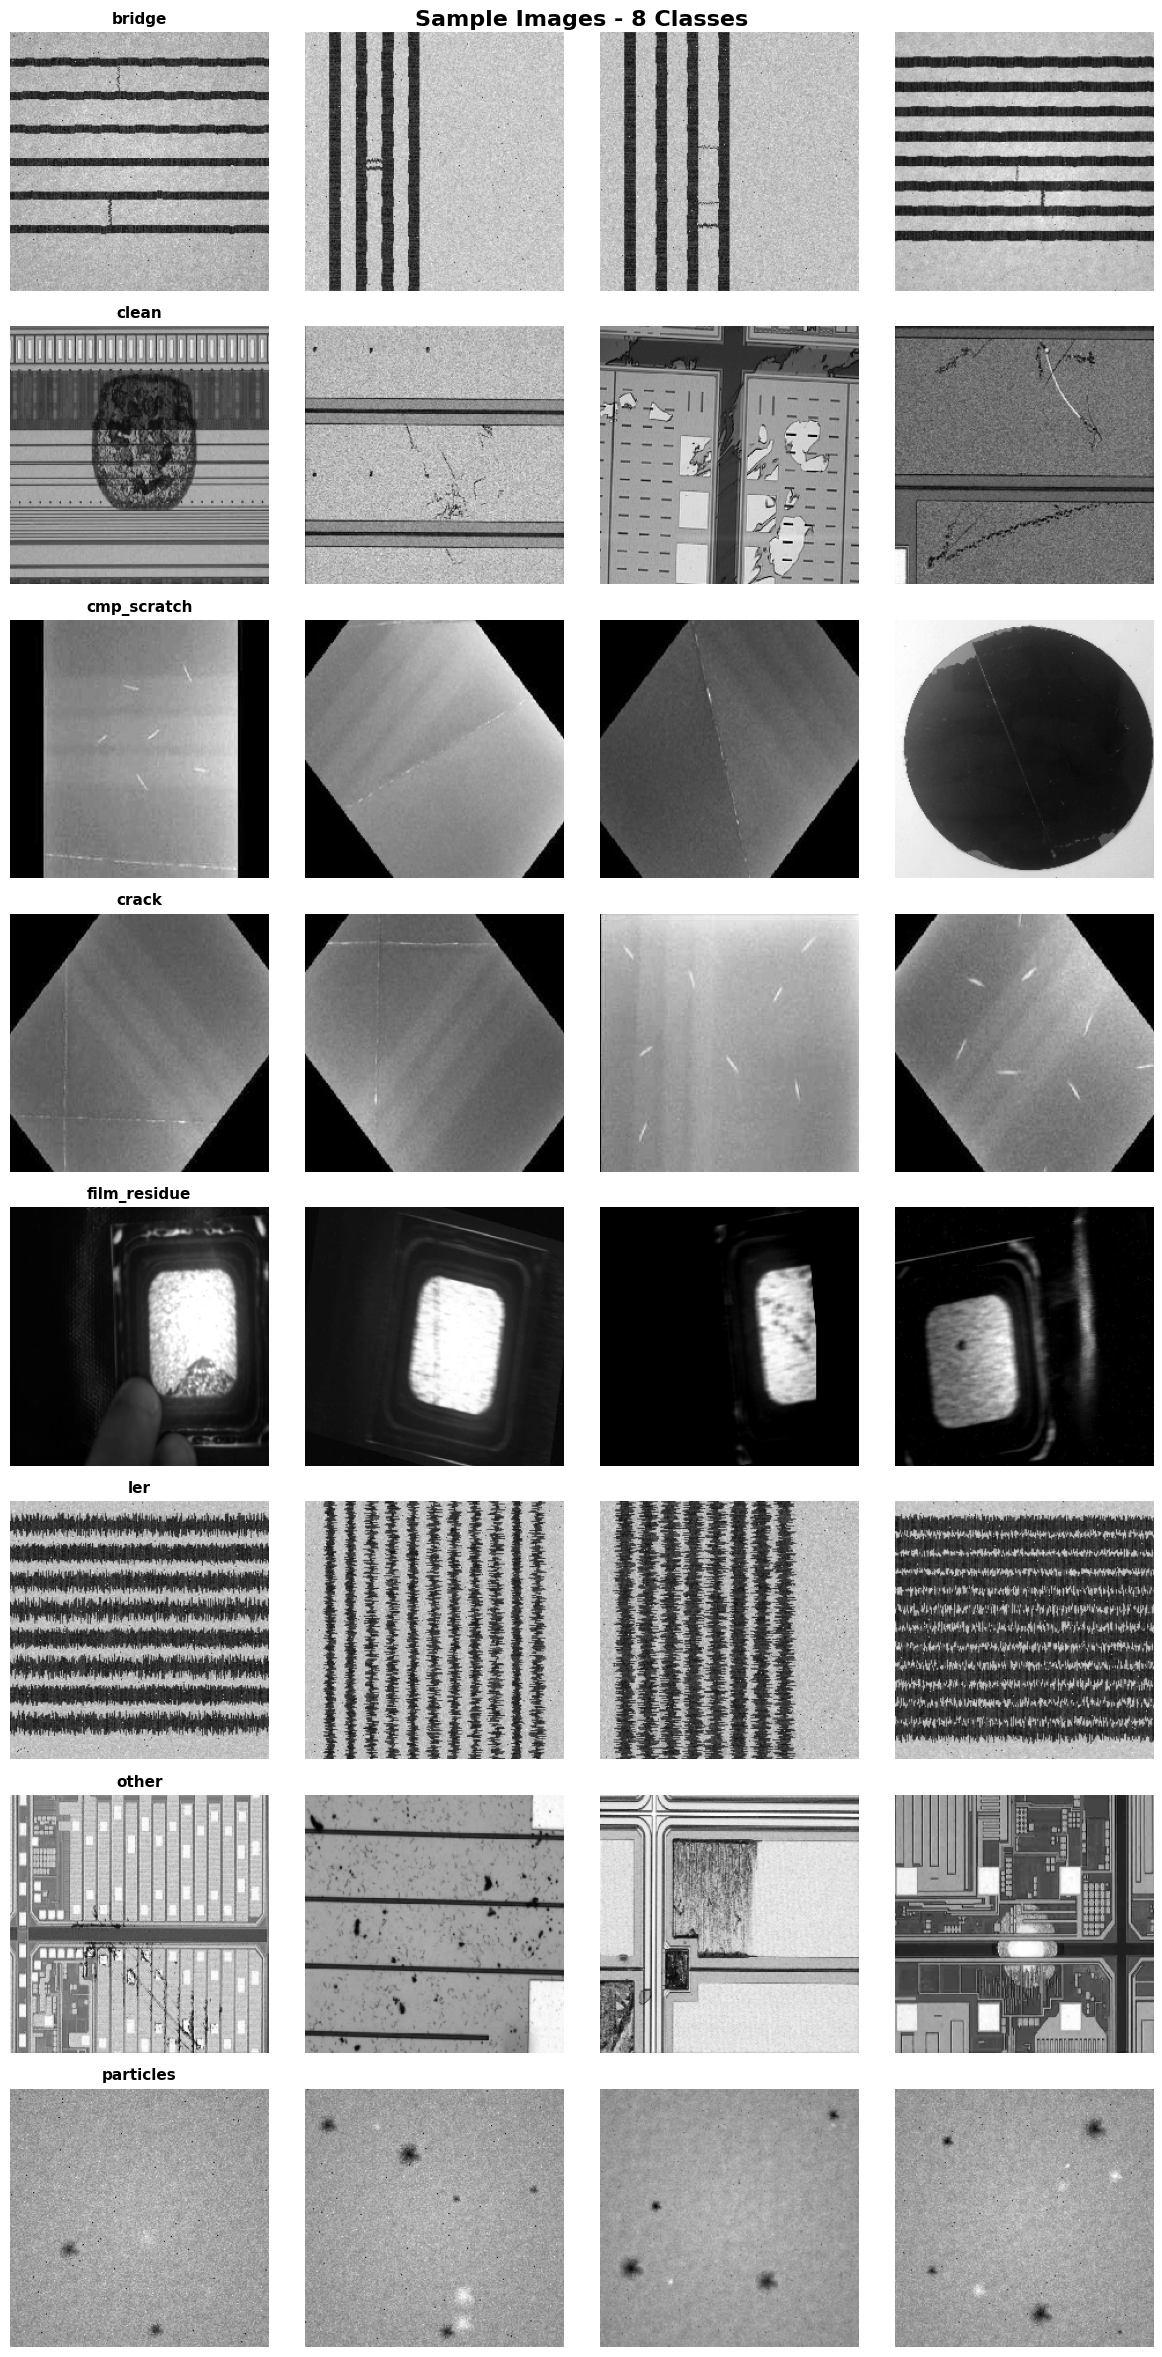

✅ Samples saved


In [6]:
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(12, 3*NUM_CLASSES))
fig.suptitle('Sample Images - 8 Classes', fontsize=16, fontweight='bold')

for class_idx, class_name in enumerate(CLASS_NAMES):
    indices = [i for i, x in enumerate(train_labels) if x == class_idx]
    if len(indices) > 0:
        samples = np.random.choice(indices, min(4, len(indices)), replace=False)
        for i, idx in enumerate(samples):
            axes[class_idx, i].imshow(X_train[idx].squeeze(), cmap='gray')
            axes[class_idx, i].axis('off')
            if i == 0:
                axes[class_idx, i].set_title(class_name, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'samples_8class.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Samples saved")

## 5. Build Model

In [7]:
def build_model(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    inputs = layers.Input(shape=(*img_size, 1))
    x = layers.Concatenate()([inputs, inputs, inputs])
    
    base_model = MobileNetV3Small(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )
    base_model.trainable = False
    
    x = base_model(x, training=False)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs, outputs), base_model

model, base_model = build_model()

print("="*70)
print("MODEL ARCHITECTURE")
print("="*70)
print(f"Total parameters: {model.count_params():,}")
print(f"Trainable: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print("="*70)

MODEL ARCHITECTURE
Total parameters: 1,122,296
Trainable: 182,408


## 6. Phase 1: Train Classifier Head

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(INITIAL_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

callbacks_p1 = [
    ModelCheckpoint(os.path.join(OUTPUT_DIR, 'phase1_best.h5'), monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
]

print("\n" + "="*70)
print("PHASE 1: Training Classifier Head")
print("="*70)

history_p1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=INITIAL_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_p1,
    verbose=1
)

print("✅ Phase 1 complete")


PHASE 1: Training Classifier Head
Epoch 1/5
565/565 [==============================] - ETA: 0s - loss: 1.6590 - accuracy: 0.3934 - precision: 0.5056 - recall: 0.1887
Epoch 1: val_accuracy improved from -inf to 0.19920, saving model to C:\Mugi\Projects\IISE\AI model\outputs\phase1_best.h5


c:\anaconda\envs\iesa\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


565/565 [==============================] - 177s 303ms/step - loss: 1.6590 - accuracy: 0.3934 - precision: 0.5056 - recall: 0.1887 - val_loss: 1.6171 - val_accuracy: 0.1992 - val_precision: 0.1751 - val_recall: 0.0526 - lr: 0.0010
Epoch 2/5
565/565 [==============================] - ETA: 0s - loss: 1.3118 - accuracy: 0.5007 - precision: 0.5829 - recall: 0.3196
Epoch 2: val_accuracy improved from 0.19920 to 0.53386, saving model to C:\Mugi\Projects\IISE\AI model\outputs\phase1_best.h5
565/565 [==============================] - 144s 254ms/step - loss: 1.3118 - accuracy: 0.5007 - precision: 0.5829 - recall: 0.3196 - val_loss: 1.3406 - val_accuracy: 0.5339 - val_precision: 0.6265 - val_recall: 0.4183 - lr: 0.0010
Epoch 3/5
565/565 [==============================] - ETA: 0s - loss: 1.2293 - accuracy: 0.5248 - precision: 0.6133 - recall: 0.3581
Epoch 3: val_accuracy improved from 0.53386 to 0.53466, saving model to C:\Mugi\Projects\IISE\AI model\outputs\phase1_best.h5
565/565 [===============

## 7. Phase 2: Fine-Tune Entire Model

In [9]:
base_model.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

\n# Calculate class weights to handle imbalance\nfrom sklearn.utils.class_weight import compute_class_weight\nimport numpy as np\n\nclass_weights = compute_class_weight(\n    class_weight='balanced',\n    classes=np.unique(train_labels),\n    y=train_labels\n)\nclass_weight_dict = dict(enumerate(class_weights))\nprint(f'Class weights: {class_weight_dict}')\n\ncallbacks_p2 = [
    ModelCheckpoint(os.path.join(OUTPUT_DIR, 'best_model_8class.h5'), monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    TensorBoard(log_dir=os.path.join(OUTPUT_DIR, 'logs'))
]

print("\n" + "="*70)
print("PHASE 2: Fine-Tuning Entire Model")
print("="*70)

history_p2 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=FINE_TUNE_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_p2,
    class_weight=class_weight_dict,\n    verbose=1
)

model.save(os.path.join(OUTPUT_DIR, 'final_model_8class.h5'))
print("✅ Phase 2 complete, model saved")


PHASE 2: Fine-Tuning Entire Model
Epoch 1/20
565/565 [==============================] - ETA: 0s - loss: 0.8157 - accuracy: 0.6557 - precision_1: 0.7352 - recall_1: 0.5681
Epoch 1: val_accuracy improved from -inf to 0.68924, saving model to C:\Mugi\Projects\IISE\AI model\outputs\best_model_8class.h5
565/565 [==============================] - 325s 549ms/step - loss: 0.8157 - accuracy: 0.6557 - precision_1: 0.7352 - recall_1: 0.5681 - val_loss: 1.2397 - val_accuracy: 0.6892 - val_precision_1: 0.7749 - val_recall_1: 0.6335 - lr: 1.0000e-04
Epoch 2/20
565/565 [==============================] - ETA: 0s - loss: 0.6598 - accuracy: 0.6973 - precision_1: 0.7523 - recall_1: 0.6371
Epoch 2: val_accuracy did not improve from 0.68924
565/565 [==============================] - 307s 543ms/step - loss: 0.6598 - accuracy: 0.6973 - precision_1: 0.7523 - recall_1: 0.6371 - val_loss: 1.0779 - val_accuracy: 0.6454 - val_precision_1: 0.6987 - val_recall_1: 0.5562 - lr: 1.0000e-04
Epoch 3/20
565/565 [=======

## 8. Training History

NameError: name 'history_p1' is not defined

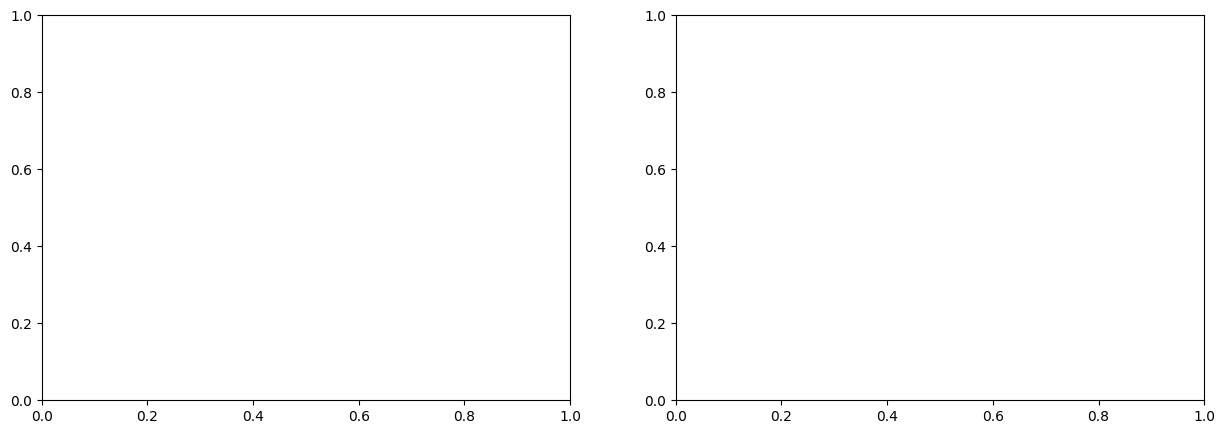

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

acc = history_p1.history['accuracy'] + history_p2.history['accuracy']
val_acc = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
loss = history_p1.history['loss'] + history_p2.history['loss']
val_loss = history_p1.history['val_loss'] + history_p2.history['val_loss']

ax1.plot(acc, label='Train', linewidth=2)
ax1.plot(val_acc, label='Val', linewidth=2)
ax1.axvline(INITIAL_EPOCHS-0.5, color='red', linestyle='--', alpha=0.7, label='Fine-tune starts')
ax1.set_title('Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(loss, label='Train', linewidth=2)
ax2.plot(val_loss, label='Val', linewidth=2)
ax2.axvline(INITIAL_EPOCHS-0.5, color='red', linestyle='--', alpha=0.7, label='Fine-tune starts')
ax2.set_title('Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'history_8class.png'), dpi=150)
plt.show()
print("✅ History saved")

## 9. Evaluate on Test Set

In [ ]:
best_model = keras.models.load_model(os.path.join(OUTPUT_DIR, 'best_model_8class.h5'))

test_loss, test_acc, test_prec, test_rec = best_model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=1)

print("\n" + "="*70)
print("TEST RESULTS")
print("="*70)
print(f"Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1-Score:  {2*(test_prec*test_rec)/(test_prec+test_rec):.4f}")
print("="*70)

## 10. Confusion Matrix

In [ ]:
y_pred = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i,j] = f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)"

sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
            linewidths=1, linecolor='gray', ax=ax,
            cbar_kws={'label': 'Number of Predictions'})

ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label', fontsize=13, fontweight='bold')
ax.set_title('Confusion Matrix - 8 Classes (12,516 Images)', fontsize=15, fontweight='bold', pad=20)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_8class.png'), dpi=200)
plt.show()
print("✅ Confusion matrix saved")

## 11. Classification Report

In [ ]:
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
print("="*70)

report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
with open(os.path.join(OUTPUT_DIR, 'report_8class.json'), 'w') as f:
    json.dump(report, f, indent=2)
print("\n✅ Report saved")

## 12. Export to TFLite

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = os.path.join(OUTPUT_DIR, 'model_8class.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

h5_size = os.path.getsize(os.path.join(OUTPUT_DIR, 'best_model_8class.h5')) / (1024*1024)
tflite_size = os.path.getsize(tflite_path) / (1024*1024)

print("\n" + "="*70)
print("MODEL EXPORT")
print("="*70)
print(f"Keras (.h5):     {h5_size:.2f} MB")
print(f"TFLite (.tflite): {tflite_size:.2f} MB ({(1-tflite_size/h5_size)*100:.1f}% reduction)")
print("="*70)
print(f"\n✅ TFLite model: {tflite_path}")

## 13. Summary

In [ ]:
summary = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset': {
        'classes': CLASS_NAMES,
        'train': X_train.shape[0],
        'val': X_val.shape[0],
        'test': X_test.shape[0],
        'total': X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
    },
    'performance': {
        'accuracy': float(test_acc),
        'precision': float(test_prec),
        'recall': float(test_rec),
        'f1': float(2*(test_prec*test_rec)/(test_prec+test_rec))
    }
}

with open(os.path.join(OUTPUT_DIR, 'summary_8class.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*70)
print("TRAINING COMPLETE - 8 CLASS DEFECT DETECTION")
print("="*70)
print(f"Dataset: {summary['dataset']['total']} images")
print(f"Test Accuracy: {summary['performance']['accuracy']:.4f} ({summary['performance']['accuracy']*100:.2f}%)")
print(f"\nOutputs: {OUTPUT_DIR}")
print("="*70)
print("\n🚀 Model ready for deployment!")

In [1]:
import tensorflow as tf

# Configure GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable memory growth
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        
        # Set memory limit (optional, adjust based on your GPU)
        tf.config.set_logical_device_configuration(
            gpus[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit=4096)]  # 4GB
        )
        print(f"✅ GPU Available: {len(gpus)} device(s)")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️  No GPU detected, using CPU")

⚠️  No GPU detected, using CPU
